In [1]:
import torch
from torch.utils.data import Dataset,DataLoader
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class Pharma_dataset(Dataset):
  def __init__(self,path):
    """
    path is a string containing the path to the pkl dataset
    """
    super().__init__()   
    #X is a list with each element of the list containing a 1024 time series data 
    #y is a list with containing the name of the chemical corresponding to X
    self.y, self.X = pickle.load(open(path, 'rb'))
    names = sorted(list(set(self.y)))
    self.mapping = {names[i]:i for i in range(len(names))}   #Maps each material name to a number

  def __len__(self):
    return len(self.y)

  def __getitem__(self,index):
    data = torch.Tensor(self.X[index]) #of shape (1,1024)
    data = data/data.max()
    label = self.mapping[self.y[index]]
    return data,label

In [3]:
test_set = Pharma_dataset("Pharma_test.pkl")
x_axis = np.linspace(0,3275,1024)

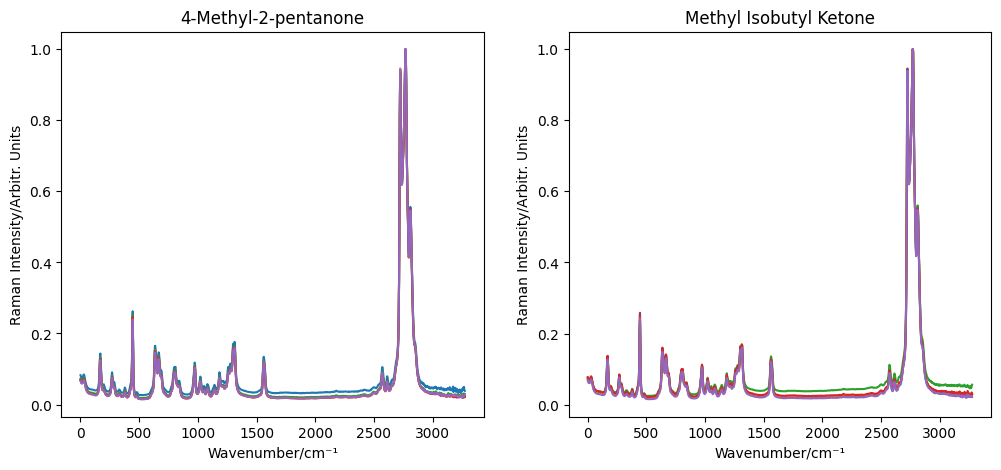

In [5]:
indices_3 = [76,67,68,69,75]
indices_23 = [506,507,508,509,510]

fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(12,5))

for i in indices_3:
    x = (test_set[i][0]-test_set[i][0].min())/(test_set[i][0].max()-test_set[i][0].min())
    ax[0].plot(x_axis,test_set[i][0].squeeze())
    ax[0].set_title("4-Methyl-2-pentanone")
    ax[0].set_xlabel("Wavenumber/cm⁻¹")
    ax[0].set_ylabel("Raman Intensity/Arbitr. Units")

for i in indices_23:
    x = (test_set[i][0]-test_set[i][0].min())/(test_set[i][0].max()-test_set[i][0].min())
    ax[1].plot(x_axis,test_set[i][0].squeeze())
    ax[1].set_title("Methyl Isobutyl Ketone")
    ax[1].set_xlabel("Wavenumber/cm⁻¹")
    ax[1].set_ylabel("Raman Intensity/Arbitr. Units")

plt.savefig("output.pdf")

In [5]:
print(test_set.mapping["4-Methyl-2-pentanone"],test_set.mapping["Methyl Isobutyl Ketone"])

3 23
